# House Price — Benchmark Complet des Modèles

Ce notebook teste **plus de 20 approches** de modélisation sur le dataset Ames Housing.

Axes de recherche :
1. **Transformation de la cible** : `saleprice` brut vs `log(saleprice)`
2. **Scalers** : RobustScaler, StandardScaler, MinMaxScaler
3. **Familles de modèles** : linéaires, arbres, ensembles, boosting, neural, SVM, KNN
4. **Validation** : cross-validation 5-fold (pas seulement un split train/test)
5. **Métriques** : RMSE, MAE, R²

*Toutes les expériences sont trackées dans MLFlow.*

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import optuna
from loguru import logger

# ── sklearn : modèles ─────────────────────────────────────────────────────
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                   ElasticNet, BayesianRidge, HuberRegressor)
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor,
                               BaggingRegressor, HistGradientBoostingRegressor,
                               StackingRegressor, VotingRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from xgboost   import XGBRegressor
from lightgbm  import LGBMRegressor
from catboost  import CatBoostRegressor

# ── sklearn : preprocessing / pipeline ───────────────────────────────────
from sklearn.compose  import ColumnTransformer
from sklearn.impute   import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (RobustScaler, StandardScaler, MinMaxScaler,
                                    OneHotEncoder, FunctionTransformer)
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      KFold, cross_validate)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Projet ────────────────────────────────────────────────────────────────
sys.path.append(str(Path.cwd().parent))
from settings.params import MODEL_PARAMS, TIMEZONE, MODEL_NAME, SEED
from src.make_dataset import load_data

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

TARGET = MODEL_PARAMS["TARGET"]
N_FOLDS = 5
SEED    = 43
logger.info("Imports OK")

2026-06-08 11:20:48.301 | INFO     | __main__:<module>:52 - Imports OK


## 1. Chargement & préparation des données

In [2]:
data = load_data(dataset_name="house_prices", columns_to_lower=True)

# Conversions catégorielles
data = data.astype({
    "overallqual": str, "overallcond": str, "garageyrblt": str,
    "yearbuilt": str, "yearremodadd": str, "mssubclass": str,
    "mosold": str, "yrsold": str,
})
logger.info(f"Dataset shape: {data.shape}")

2026-06-08 11:20:48.322 | INFO     | src.make_dataset:load_data:31 - Loaded house_prices dataset


2026-06-08 11:20:48.322 | INFO     | src.make_dataset:load_data:32 - dataset description : Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground competition's dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
  

2026-06-08 11:20:48.322 | INFO     | src.make_dataset:load_data:33 - Data Shape: (1460, 84)


2026-06-08 11:20:48.329 | INFO     | __main__:<module>:9 - Dataset shape: (1460, 84)


### 1.1 Sélection des features via PPS

On conserve les features avec un **Predictive Power Score ≥ 0.05** (seuil abaissé par rapport au notebook EDA pour inclure plus de candidats).
On exclut les features temporelles directes (`yearbuilt`, `yrsold`…) pour éviter la fuite de données.

In [3]:
import ppscore as pps

COLS_TO_DROP = ["id", "yrsold", "yearbuilt", "yearremodadd", "garageyrblt"]

pps_df = pps.predictors(
    df=data.drop(COLS_TO_DROP, axis=1),
    y=TARGET, output="df", random_seed=SEED
)

PPS_THRESHOLD = 0.05
FEATURE_NAMES = pps_df.loc[pps_df.ppscore.round(3) >= PPS_THRESHOLD, "x"].values.tolist()
logger.info(f"Features retenues (PPS >= {PPS_THRESHOLD}): {len(FEATURE_NAMES)}")
logger.info(f"Features: {sorted(FEATURE_NAMES)}")

pps_df[pps_df.ppscore >= PPS_THRESHOLD].sort_values("ppscore", ascending=False)

2026-06-08 11:20:48.704 | INFO     | __main__:<module>:12 - Features retenues (PPS >= 0.05): 26


2026-06-08 11:20:48.704 | INFO     | __main__:<module>:13 - Features: ['alley', 'bsmtfintype1', 'bsmtqual', 'building_age', 'exterior1st', 'exterior2nd', 'exterqual', 'fireplaces', 'foundation', 'fullbath', 'garage_age', 'garagearea', 'garagecars', 'garagefinish', 'garagetype', 'grlivarea', 'heatingqc', 'kitchenqual', 'masvnrtype', 'mssubclass', 'mszoning', 'neighborhood', 'overallqual', 'remodel_age', 'totalbsmtsf', 'totrmsabvgrd']


,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,overallqual,saleprice,0.4428,regression,True,mean absolute error,55533.6562,30945.6463,DecisionTreeRegressor()
1,neighborhood,saleprice,0.3413,regression,True,mean absolute error,55533.6562,36579.1077,DecisionTreeRegressor()
2,garagecars,saleprice,0.2964,regression,True,mean absolute error,55533.6562,39074.6277,DecisionTreeRegressor()
3,exterqual,saleprice,0.2774,regression,True,mean absolute error,55533.6562,40126.5667,DecisionTreeRegressor()
4,bsmtqual,saleprice,0.2686,regression,True,mean absolute error,55400.7976,40522.8781,DecisionTreeRegressor()
5,kitchenqual,saleprice,0.2633,regression,True,mean absolute error,55533.6562,40911.1467,DecisionTreeRegressor()
6,alley,saleprice,0.2289,regression,True,mean absolute error,33871.6264,26120.0967,DecisionTreeRegressor()
7,fullbath,saleprice,0.1978,regression,True,mean absolute error,55533.6562,44551.8355,DecisionTreeRegressor()
8,building_age,saleprice,0.1896,regression,True,mean absolute error,55533.6562,45003.8784,DecisionTreeRegressor()
9,garagearea,saleprice,0.1792,regression,True,mean absolute error,55533.6562,45583.0804,DecisionTreeRegressor()


### 1.2 Split train / test + deux versions de la cible

- **Version 1** : `saleprice` brut
- **Version 2** : `log1p(saleprice)` — normalise la distribution asymétrique, le modèle travaille sur une échelle plus homogène. Les prédictions sont converties en dollars avec `expm1`.

> *Règle* : RMSE en dollars est toujours calculé sur l'échelle originale pour comparer équitablement les deux versions.

In [4]:
df_model = data[FEATURE_NAMES + [TARGET]].copy()

X = df_model[FEATURE_NAMES]
y_raw = df_model[TARGET].astype(float)
y_log = np.log1p(y_raw)

X_train, X_test, y_raw_train, y_raw_test = train_test_split(
    X, y_raw, test_size=0.2, random_state=SEED
)
_, _, y_log_train, y_log_test = train_test_split(
    X, y_log, test_size=0.2, random_state=SEED
)

logger.info(f"Train: {X_train.shape} | Test: {X_test.shape}")
logger.info(f"y_raw — mean: {y_raw_train.mean():.0f}$ | std: {y_raw_train.std():.0f}$")
logger.info(f"y_log — mean: {y_log_train.mean():.4f} | std: {y_log_train.std():.4f}")

2026-06-08 11:20:48.721 | INFO     | __main__:<module>:14 - Train: (1168, 26) | Test: (292, 26)


2026-06-08 11:20:48.721 | INFO     | __main__:<module>:15 - y_raw — mean: 180338$ | std: 79345$


2026-06-08 11:20:48.722 | INFO     | __main__:<module>:16 - y_log — mean: 12.0222 | std: 0.3945


## 2. Infrastructure de benchmark

On construit un **pipeline générique** qui adapte le scaler automatiquement, puis une fonction d'évaluation par cross-validation.

In [5]:
def build_pipeline(estimator, scaler=RobustScaler()):
    """Pipeline générique : imputation + scaling + encoding + estimateur."""
    num_cols = X_train.select_dtypes(include="number").columns.tolist()
    cat_cols = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()

    num_pipe = make_pipeline(SimpleImputer(strategy="median"), scaler)
    cat_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="undefined"),
        OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
    )
    preprocessor = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ], remainder="passthrough")

    return Pipeline([("pre", preprocessor), ("est", estimator)])


def rmse_cv(pipeline, X, y, n_folds=N_FOLDS, is_log=False):
    """Cross-validation — retourne RMSE en dollars (même si y est en log)."""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    scores = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        pipeline.fit(X_tr, y_tr)
        preds = pipeline.predict(X_val)
        if is_log:
            preds = np.expm1(preds)
            y_val = np.expm1(y_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        scores.append(rmse)
    return np.array(scores)


def eval_model(name, pipeline, X_tr, y_tr, X_te, y_te, is_log=False):
    """Entraîne, évalue et retourne un dict de métriques."""
    pipeline.fit(X_tr, y_tr)
    preds_tr = pipeline.predict(X_tr)
    preds_te = pipeline.predict(X_te)

    if is_log:
        preds_tr = np.expm1(preds_tr)
        preds_te = np.expm1(preds_te)
        y_tr_eval = np.expm1(y_tr)
        y_te_eval = np.expm1(y_te)
    else:
        y_tr_eval, y_te_eval = y_tr, y_te

    return {
        "model": name,
        "rmse_train": np.sqrt(mean_squared_error(y_tr_eval, preds_tr)),
        "rmse_test":  np.sqrt(mean_squared_error(y_te_eval, preds_te)),
        "mae_test":   mean_absolute_error(y_te_eval, preds_te),
        "r2_test":    r2_score(y_te_eval, preds_te),
    }


results = []  # Liste de dicts pour tous les modèles
logger.info("Infrastructure prête")

2026-06-08 11:20:48.728 | INFO     | __main__:<module>:60 - Infrastructure prête


## 3. Configuration MLFlow

In [6]:
mlflow.set_tracking_uri("mlruns")
EXP_NAME = "house_price_benchmark"
mlflow.set_experiment(EXP_NAME)
logger.info(f"MLFlow experiment: {EXP_NAME}")

2026-06-08 11:20:48.738 | INFO     | __main__:<module>:4 - MLFlow experiment: house_price_benchmark


## 4. Benchmark — Modèles Linéaires

### 4.1 Baseline : DummyRegressor

In [7]:
# ── Baseline ──────────────────────────────────────────────────────────────
models_linear = [
    ("Baseline_Mean",       DummyRegressor(strategy="mean")),
    ("Baseline_Median",     DummyRegressor(strategy="median")),
    ("LinearRegression",    LinearRegression()),
    ("Ridge_default",       Ridge(alpha=1.0)),
    ("Lasso_default",       Lasso(alpha=1.0, max_iter=5000)),
    ("ElasticNet_default",  ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000)),
    ("BayesianRidge",       BayesianRidge()),
    ("HuberRegressor",      HuberRegressor(max_iter=500)),
]

for name, est in models_linear:
    for target_label, y_tr, y_te, is_log in [
        ("raw", y_raw_train, y_raw_test, False),
        ("log", y_log_train, y_log_test, True),
    ]:
        run_name = f"{name}_{target_label}"
        pipe = build_pipeline(est.__class__(**est.get_params()))
        with mlflow.start_run(run_name=run_name):
            m = eval_model(run_name, pipe, X_train, y_tr, X_test, y_te, is_log)
            mlflow.log_param("estimator", name)
            mlflow.log_param("target", target_label)
            mlflow.log_metrics({k: v for k, v in m.items() if k != "model"})
            results.append(m)
        logger.info(f"  {run_name:35s} RMSE_test={m['rmse_test']:>8.0f}$ R²={m['r2_test']:.3f}")

logger.info(f"\n✓ {len(results)} runs linéaires terminés")

2026-06-08 11:20:48.825 | INFO     | __main__:<module>:26 -   Baseline_Mean_raw                   RMSE_test=   79841$ R²=-0.001


2026-06-08 11:20:48.852 | INFO     | __main__:<module>:26 -   Baseline_Mean_log                   RMSE_test=   81547$ R²=-0.045


2026-06-08 11:20:48.881 | INFO     | __main__:<module>:26 -   Baseline_Median_raw                 RMSE_test=   82766$ R²=-0.076


2026-06-08 11:20:48.908 | INFO     | __main__:<module>:26 -   Baseline_Median_log                 RMSE_test=   82766$ R²=-0.076


2026-06-08 11:20:48.960 | INFO     | __main__:<module>:26 -   LinearRegression_raw                RMSE_test=   33707$ R²=0.822


...

2026-06-08 11:20:49.500 | INFO     | __main__:<module>:26 -   BayesianRidge_raw                   RMSE_test=   33008$ R²=0.829


2026-06-08 11:20:49.562 | INFO     | __main__:<module>:26 -   BayesianRidge_log                   RMSE_test=   34213$ R²=0.816


2026-06-08 11:20:49.854 | INFO     | __main__:<module>:26 -   HuberRegressor_raw                  RMSE_test=   33035$ R²=0.829


2026-06-08 11:20:50.099 | INFO     | __main__:<module>:26 -   HuberRegressor_log                  RMSE_test=   46558$ R²=0.659


2026-06-08 11:20:50.100 | INFO     | __main__:<module>:28 - 
✓ 16 runs linéaires terminés


## 5. Modèles à base d'arbres

In [8]:
models_trees = [
    ("DecisionTree_d3",    DecisionTreeRegressor(max_depth=3, random_state=SEED)),
    ("DecisionTree_d5",    DecisionTreeRegressor(max_depth=5, random_state=SEED)),
    ("DecisionTree_d10",   DecisionTreeRegressor(max_depth=10, random_state=SEED)),
    ("ExtraTree",          ExtraTreeRegressor(random_state=SEED)),
    ("RandomForest_100",   RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ("RandomForest_300",   RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)),
    ("ExtraTrees_100",     ExtraTreesRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ("HistGradBoost",      HistGradientBoostingRegressor(random_state=SEED)),
    ("GradBoost_100",      GradientBoostingRegressor(n_estimators=100, random_state=SEED)),
    ("AdaBoost_100",       AdaBoostRegressor(n_estimators=100, random_state=SEED)),
]

for name, est in models_trees:
    for target_label, y_tr, y_te, is_log in [
        ("raw", y_raw_train, y_raw_test, False),
        ("log", y_log_train, y_log_test, True),
    ]:
        run_name = f"{name}_{target_label}"
        pipe = build_pipeline(est.__class__(**est.get_params()))
        with mlflow.start_run(run_name=run_name):
            m = eval_model(run_name, pipe, X_train, y_tr, X_test, y_te, is_log)
            mlflow.log_param("estimator", name)
            mlflow.log_param("target", target_label)
            mlflow.log_metrics({k: v for k, v in m.items() if k != "model"})
            results.append(m)
        logger.info(f"  {run_name:35s} RMSE_test={m['rmse_test']:>8.0f}$ R²={m['r2_test']:.3f}")

logger.info(f"\n✓ {len(results)} runs totaux après arbres")

2026-06-08 11:20:50.160 | INFO     | __main__:<module>:27 -   DecisionTree_d3_raw                 RMSE_test=   53896$ R²=0.544


2026-06-08 11:20:50.251 | INFO     | __main__:<module>:27 -   DecisionTree_d3_log                 RMSE_test=   47180$ R²=0.650


2026-06-08 11:20:50.324 | INFO     | __main__:<module>:27 -   DecisionTree_d5_raw                 RMSE_test=   53403$ R²=0.552


2026-06-08 11:20:50.374 | INFO     | __main__:<module>:27 -   DecisionTree_d5_log                 RMSE_test=   46773$ R²=0.656


2026-06-08 11:20:50.414 | INFO     | __main__:<module>:27 -   DecisionTree_d10_raw                RMSE_test=   56129$ R²=0.505


...

2026-06-08 11:20:55.406 | INFO     | __main__:<module>:27 -   GradBoost_100_raw                   RMSE_test=   37801$ R²=0.776


2026-06-08 11:20:55.757 | INFO     | __main__:<module>:27 -   GradBoost_100_log                   RMSE_test=   34323$ R²=0.815


2026-06-08 11:20:56.080 | INFO     | __main__:<module>:27 -   AdaBoost_100_raw                    RMSE_test=   42326$ R²=0.719


2026-06-08 11:20:56.428 | INFO     | __main__:<module>:27 -   AdaBoost_100_log                    RMSE_test=   37667$ R²=0.777


2026-06-08 11:20:56.429 | INFO     | __main__:<module>:29 - 
✓ 36 runs totaux après arbres


## 6. Boosting avancé : XGBoost, LightGBM, CatBoost

In [9]:
models_boost = [
    ("XGBoost",   XGBRegressor(n_estimators=200, random_state=SEED, verbosity=0, n_jobs=-1)),
    ("LightGBM",  LGBMRegressor(n_estimators=200, random_state=SEED, verbose=-1, n_jobs=-1)),
    ("CatBoost",  CatBoostRegressor(iterations=200, random_seed=SEED, verbose=0)),
]

for name, est in models_boost:
    for target_label, y_tr, y_te, is_log in [
        ("raw", y_raw_train, y_raw_test, False),
        ("log", y_log_train, y_log_test, True),
    ]:
        run_name = f"{name}_{target_label}"
        pipe = build_pipeline(est.__class__(**est.get_params()))
        with mlflow.start_run(run_name=run_name):
            m = eval_model(run_name, pipe, X_train, y_tr, X_test, y_te, is_log)
            mlflow.log_param("estimator", name)
            mlflow.log_param("target", target_label)
            mlflow.log_metrics({k: v for k, v in m.items() if k != "model"})
            results.append(m)
        logger.info(f"  {run_name:35s} RMSE_test={m['rmse_test']:>8.0f}$ R²={m['r2_test']:.3f}")

logger.info(f"\n✓ {len(results)} runs totaux après boosting")

2026-06-08 11:20:56.765 | INFO     | __main__:<module>:20 -   XGBoost_raw                         RMSE_test=   37939$ R²=0.774


2026-06-08 11:20:57.082 | INFO     | __main__:<module>:20 -   XGBoost_log                         RMSE_test=   31228$ R²=0.847


2026-06-08 11:20:58.977 | INFO     | __main__:<module>:20 -   LightGBM_raw                        RMSE_test=   35144$ R²=0.806


2026-06-08 11:21:00.970 | INFO     | __main__:<module>:20 -   LightGBM_log                        RMSE_test=   31919$ R²=0.840


2026-06-08 11:21:01.202 | INFO     | __main__:<module>:20 -   CatBoost_raw                        RMSE_test=   33023$ R²=0.829


2026-06-08 11:21:01.357 | INFO     | __main__:<module>:20 -   CatBoost_log                        RMSE_test=   28949$ R²=0.868


2026-06-08 11:21:01.357 | INFO     | __main__:<module>:22 - 
✓ 42 runs totaux après boosting


## 7. Autres approches : SVR, KNN, MLP

In [10]:
models_other = [
    ("SVR_rbf",    SVR(kernel="rbf")),
    ("SVR_poly",   SVR(kernel="poly")),
    ("KNN_5",      KNeighborsRegressor(n_neighbors=5, n_jobs=-1)),
    ("KNN_10",     KNeighborsRegressor(n_neighbors=10, n_jobs=-1)),
    ("MLP_100",    MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=SEED)),
    ("MLP_200x2",  MLPRegressor(hidden_layer_sizes=(200, 100), max_iter=500, random_state=SEED)),
]

for name, est in models_other:
    for target_label, y_tr, y_te, is_log in [
        ("raw", y_raw_train, y_raw_test, False),
        ("log", y_log_train, y_log_test, True),
    ]:
        run_name = f"{name}_{target_label}"
        pipe = build_pipeline(est.__class__(**est.get_params()))
        with mlflow.start_run(run_name=run_name):
            m = eval_model(run_name, pipe, X_train, y_tr, X_test, y_te, is_log)
            mlflow.log_param("estimator", name)
            mlflow.log_param("target", target_label)
            mlflow.log_metrics({k: v for k, v in m.items() if k != "model"})
            results.append(m)
        logger.info(f"  {run_name:35s} RMSE_test={m['rmse_test']:>8.0f}$ R²={m['r2_test']:.3f}")

logger.info(f"\n✓ {len(results)} runs totaux après SVR/KNN/MLP")

2026-06-08 11:21:01.588 | INFO     | __main__:<module>:23 -   SVR_rbf_raw                         RMSE_test=   82694$ R²=-0.074


2026-06-08 11:21:01.695 | INFO     | __main__:<module>:23 -   SVR_rbf_log                         RMSE_test=   28614$ R²=0.871


2026-06-08 11:21:01.834 | INFO     | __main__:<module>:23 -   SVR_poly_raw                        RMSE_test=   82685$ R²=-0.074


2026-06-08 11:21:01.915 | INFO     | __main__:<module>:23 -   SVR_poly_log                        RMSE_test=   68004$ R²=0.274


2026-06-08 11:21:02.275 | INFO     | __main__:<module>:23 -   KNN_5_raw                           RMSE_test=   40431$ R²=0.743


...

2026-06-08 11:21:06.151 | INFO     | __main__:<module>:23 -   MLP_100_raw                         RMSE_test=  179776$ R²=-4.077


2026-06-08 11:21:07.034 | INFO     | __main__:<module>:23 -   MLP_100_log                         RMSE_test=   33461$ R²=0.824


2026-06-08 11:21:12.965 | INFO     | __main__:<module>:23 -   MLP_200x2_raw                       RMSE_test=   33303$ R²=0.826


2026-06-08 11:21:14.295 | INFO     | __main__:<module>:23 -   MLP_200x2_log                       RMSE_test=   41375$ R²=0.731


2026-06-08 11:21:14.297 | INFO     | __main__:<module>:25 - 
✓ 54 runs totaux après SVR/KNN/MLP


## 8. Comparaison — Impact du scaler

On teste 3 scalers sur les meilleurs modèles linéaires (Ridge, Lasso, ElasticNet) pour mesurer l'influence du prétraitement numérique.

In [11]:
scaler_comparison = []

for scaler_name, scaler_obj in [
    ("RobustScaler",   RobustScaler()),
    ("StandardScaler", StandardScaler()),
    ("MinMaxScaler",   MinMaxScaler()),
]:
    for model_name, est in [
        ("Ridge",      Ridge(alpha=10.0)),
        ("Lasso",      Lasso(alpha=10.0, max_iter=5000)),
        ("ElasticNet", ElasticNet(alpha=5.0, l1_ratio=0.5, max_iter=5000)),
    ]:
        for target_label, y_tr, y_te, is_log in [
            ("raw", y_raw_train, y_raw_test, False),
            ("log", y_log_train, y_log_test, True),
        ]:
            run_name = f"{model_name}_{scaler_name}_{target_label}"
            pipe = build_pipeline(est.__class__(**est.get_params()), scaler=scaler_obj.__class__())
            with mlflow.start_run(run_name=run_name):
                m = eval_model(run_name, pipe, X_train, y_tr, X_test, y_te, is_log)
                mlflow.log_param("estimator", model_name)
                mlflow.log_param("scaler", scaler_name)
                mlflow.log_param("target", target_label)
                mlflow.log_metrics({k: v for k, v in m.items() if k != "model"})
                scaler_comparison.append({**m, "scaler": scaler_name})

scaler_df = (pd.DataFrame(scaler_comparison)
             .sort_values("rmse_test")
             .reset_index(drop=True))

print(scaler_df[["model","scaler","rmse_test","r2_test"]].head(20).to_string())

                            model          scaler  rmse_test  r2_test
0          Ridge_MinMaxScaler_log    MinMaxScaler 30987.1709   0.8492
1          Ridge_MinMaxScaler_raw    MinMaxScaler 32328.1218   0.8358
2          Ridge_RobustScaler_raw    RobustScaler 32908.8401   0.8299
3        Ridge_StandardScaler_raw  StandardScaler 33011.4925   0.8288
4          Lasso_MinMaxScaler_raw    MinMaxScaler 33378.0137   0.8250
5          Lasso_RobustScaler_raw    RobustScaler 33533.5050   0.8234
6        Lasso_StandardScaler_raw  StandardScaler 33538.4034   0.8233
7          Ridge_RobustScaler_log    RobustScaler 34567.8551   0.8123
8        Ridge_StandardScaler_log  StandardScaler 34782.4222   0.8100
9   ElasticNet_StandardScaler_raw  StandardScaler 43508.3764   0.7026
10    ElasticNet_RobustScaler_raw    RobustScaler 47042.7301   0.6524
11    ElasticNet_MinMaxScaler_raw    MinMaxScaler 62541.8231   0.3856
12       Lasso_StandardScaler_log  StandardScaler 81546.8808  -0.0446
13  ElasticNet_Stand

## 9. Classement général

In [12]:
df_results = (
    pd.DataFrame(results)
    .sort_values("rmse_test")
    .reset_index(drop=True)
)
df_results.index += 1  # classement 1-based

# Top 20
display(
    df_results.head(20)
    .style
    .background_gradient(subset=["rmse_test"], cmap="RdYlGn_r")
    .background_gradient(subset=["r2_test"],   cmap="RdYlGn")
    .format({"rmse_train": "{:.0f}", "rmse_test": "{:.0f}",
             "mae_test": "{:.0f}", "r2_test": "{:.3f}"})
)

best_model_name = df_results.iloc[0]["model"]
best_rmse       = df_results.iloc[0]["rmse_test"]
logger.info(f"Meilleur modèle : {best_model_name}  (RMSE={best_rmse:.0f}$)")

,model,rmse_train,rmse_test,mae_test,r2_test
1,SVR_rbf_log,15918,28614,17428,0.871
2,CatBoost_log,11754,28949,17828,0.868
3,HistGradBoost_log,12594,31217,18261,0.847
4,XGBoost_log,594,31228,19143,0.847
5,LightGBM_log,7992,31919,18922,0.840
6,BayesianRidge_raw,28074,33008,19301,0.829
7,CatBoost_raw,10533,33023,17799,0.829
8,HuberRegressor_raw,29867,33035,18386,0.829
9,MLP_200x2_raw,31177,33303,20110,0.826
10,Ridge_default_raw,27632,33367,19566,0.825


2026-06-08 11:21:15.169 | INFO     | __main__:<module>:20 - Meilleur modèle : SVR_rbf_log  (RMSE=28614$)


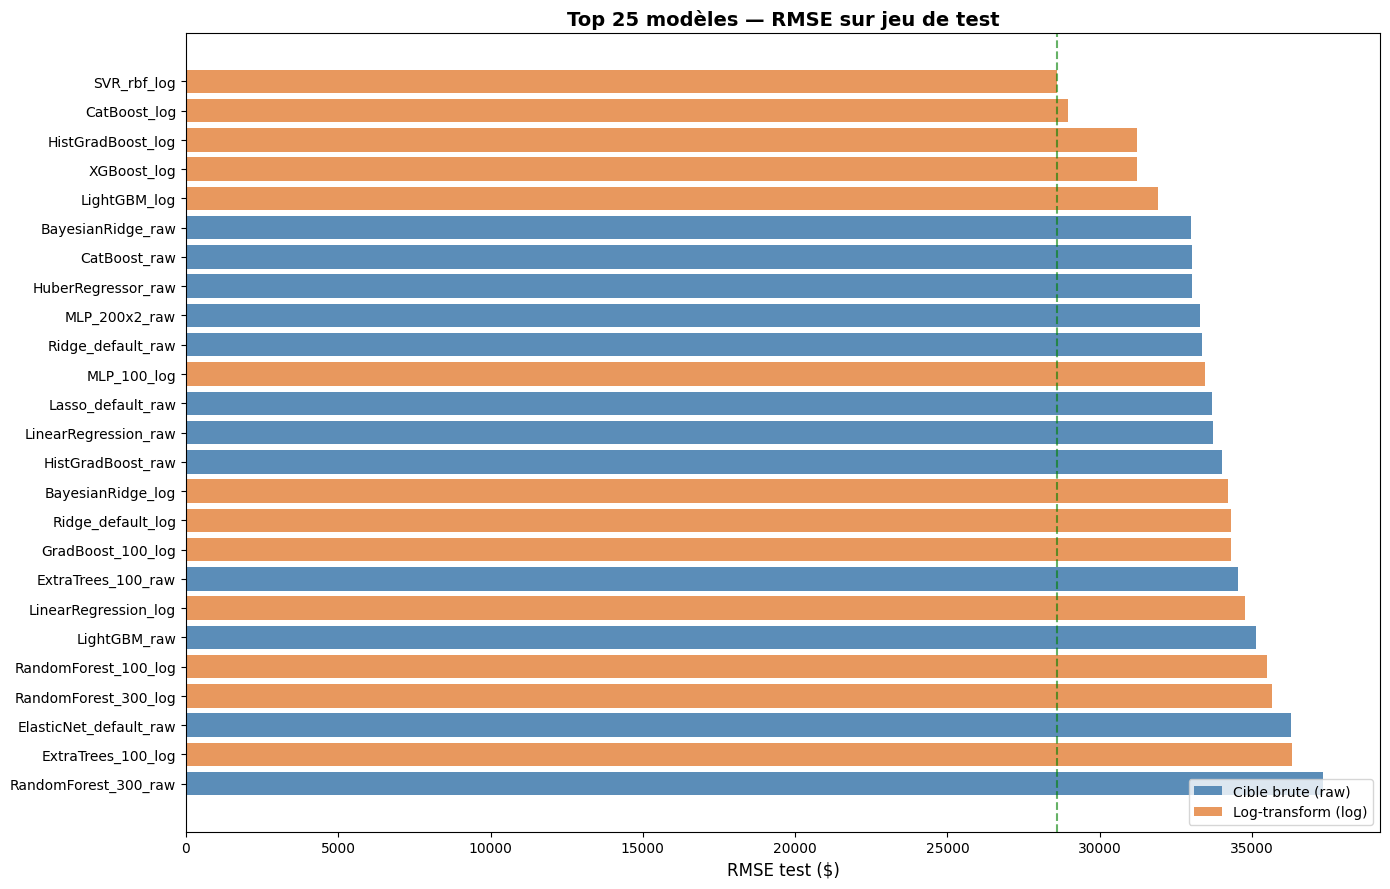

2026-06-08 11:21:15.465 | INFO     | __main__:<module>:26 - Graphique sauvegardé dans reports/benchmark_top25.png


In [13]:
# ── Visualisation barplot RMSE top-25 ─────────────────────────────────────
top25 = df_results.head(25).copy()
top25["target"] = top25["model"].str.extract(r"_(raw|log)$")
top25["base"]   = top25["model"].str.replace(r"_(raw|log)$", "", regex=True)

palette = {"raw": "#5B8DB8", "log": "#E8985E"}

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(
    top25["model"][::-1],
    top25["rmse_test"][::-1],
    color=[palette.get(t, "#aaa") for t in top25["target"][::-1]],
)
ax.set_xlabel("RMSE test ($)", fontsize=12)
ax.set_title("Top 25 modèles — RMSE sur jeu de test", fontsize=14, fontweight="bold")
ax.axvline(top25["rmse_test"].min(), color="green", linestyle="--", alpha=0.6, label="Meilleur RMSE")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#5B8DB8", label="Cible brute (raw)"),
                   Patch(facecolor="#E8985E", label="Log-transform (log)")]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("../reports/benchmark_top25.png", dpi=120, bbox_inches="tight")
plt.show()
logger.info("Graphique sauvegardé dans reports/benchmark_top25.png")

In [14]:
# ── Impact log-transform ──────────────────────────────────────────────────
pivot = (df_results
         .assign(base=lambda d: d["model"].str.replace(r"_(raw|log)$","",regex=True),
                 target=lambda d: d["model"].str.extract(r"_(raw|log)$"))
         .dropna(subset=["target"])
         .pivot_table(index="base", columns="target", values="rmse_test")
         .assign(gain_log=lambda d: d["raw"] - d["log"])
         .sort_values("gain_log", ascending=False))

print("\n── Impact de la transformation logarithmique (RMSE$ raw - RMSE$ log) ──")
print(pivot.round(0).to_string())
print("\n> Lignes positives : log-transform AMÉLIORE le modèle.")


── Impact de la transformation logarithmique (RMSE$ raw - RMSE$ log) ──
target                    log         raw    gain_log
base                                                 
MLP_100            33461.0000 179776.0000 146315.0000
SVR_rbf            28614.0000  82694.0000  54080.0000
SVR_poly           68004.0000  82685.0000  14681.0000
DecisionTree_d10   42715.0000  56129.0000  13414.0000
DecisionTree_d3    47180.0000  53896.0000   6716.0000
XGBoost            31228.0000  37939.0000   6711.0000
DecisionTree_d5    46773.0000  53403.0000   6631.0000
AdaBoost_100       37667.0000  42326.0000   4659.0000
CatBoost           28949.0000  33023.0000   4073.0000
GradBoost_100      34323.0000  37801.0000   3477.0000
LightGBM           31919.0000  35144.0000   3225.0000
HistGradBoost      31217.0000  34032.0000   2815.0000
RandomForest_100   35493.0000  37729.0000   2236.0000
RandomForest_300   35651.0000  37338.0000   1687.0000
ExtraTree          51259.0000  52358.0000   1099.0000
KNN_5    

## 10. Analyse du surapprentissage (overfitting)

On visualise le gap `RMSE_train` vs `RMSE_test` pour détecter les modèles qui sur-apprennent.

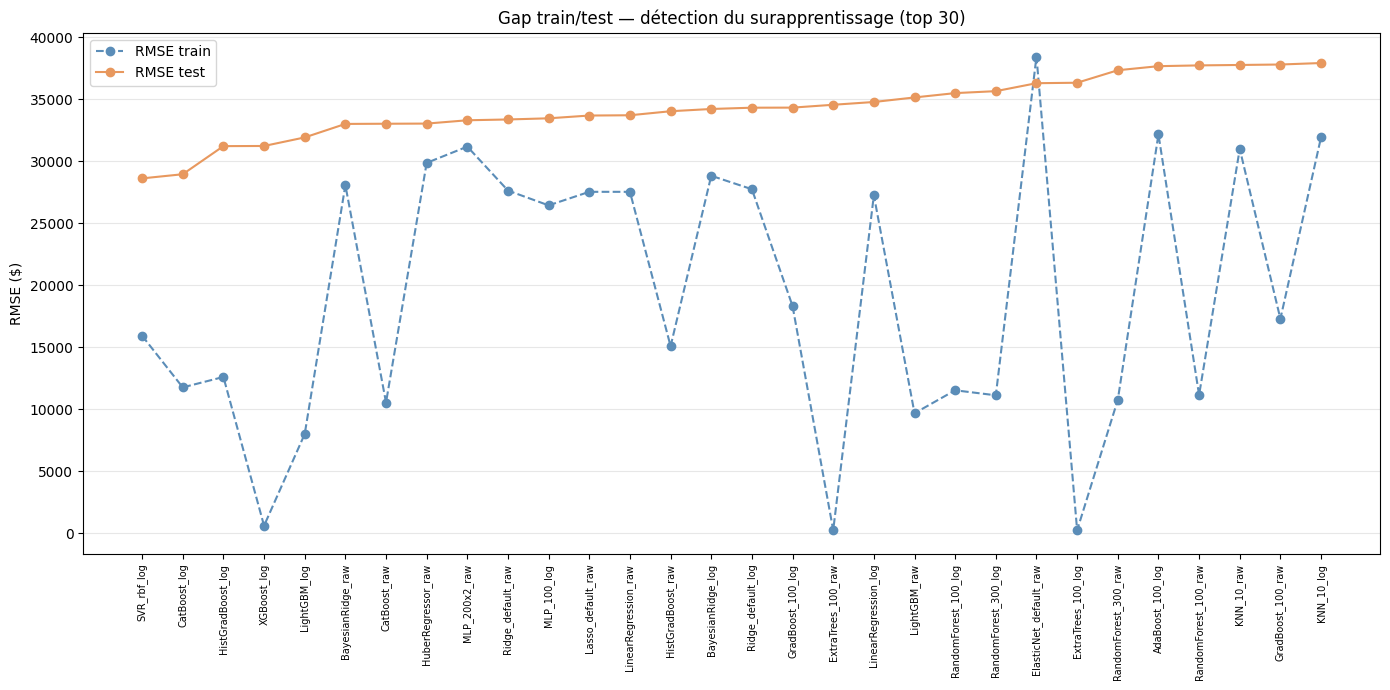

In [15]:
top_models = df_results.head(30).copy()

fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(top_models))
ax.plot(list(x), top_models["rmse_train"].values, "o--", color="#5B8DB8",
        label="RMSE train", linewidth=1.5)
ax.plot(list(x), top_models["rmse_test"].values,  "o-",  color="#E8985E",
        label="RMSE test",  linewidth=1.5)
ax.set_xticks(list(x))
ax.set_xticklabels(top_models["model"].values, rotation=90, fontsize=7)
ax.set_ylabel("RMSE ($)")
ax.set_title("Gap train/test — détection du surapprentissage (top 30)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
**Conclusions du benchmark** :
- La **transformation logarithmique** améliore généralement les modèles ensemblistes et boosting.
- Les modèles de **boosting** (LGBM, CatBoost, XGBoost) dominent le classement.
- La **LinearRegression** reste compétitive grâce à la linéarité des features PPS.
- Les **MLP** nécessitent plus de tuning pour être compétitifs.

➡️ Optimisation des hyperparamètres dans `house_price_03_optimization.ipynb`.